In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import t

# EDA

In [7]:
#url = "https://github.com/GennadiiTurutin/JSONB-indexing-vs-rel.-indexing/blob/main/bench_results.csv"

# expoting data
data = pd.read_csv ('bench_results.csv')[['label', 'run_no', 'variant', 'execution_ms']].reset_index (drop = True)
data.run_no.unique ()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [8]:
# leaving only unidexed 1mm records

indexed = data[(~data['label'].str.contains ('unindexed')) & 
    (data['label'].str.contains ('1000000'))].copy ()

def db_type (row):
    if "rel" in row['label']:
        return "rel"
    else:
        return "jsonb"

indexed['type'] = indexed.apply (db_type, axis =1) 

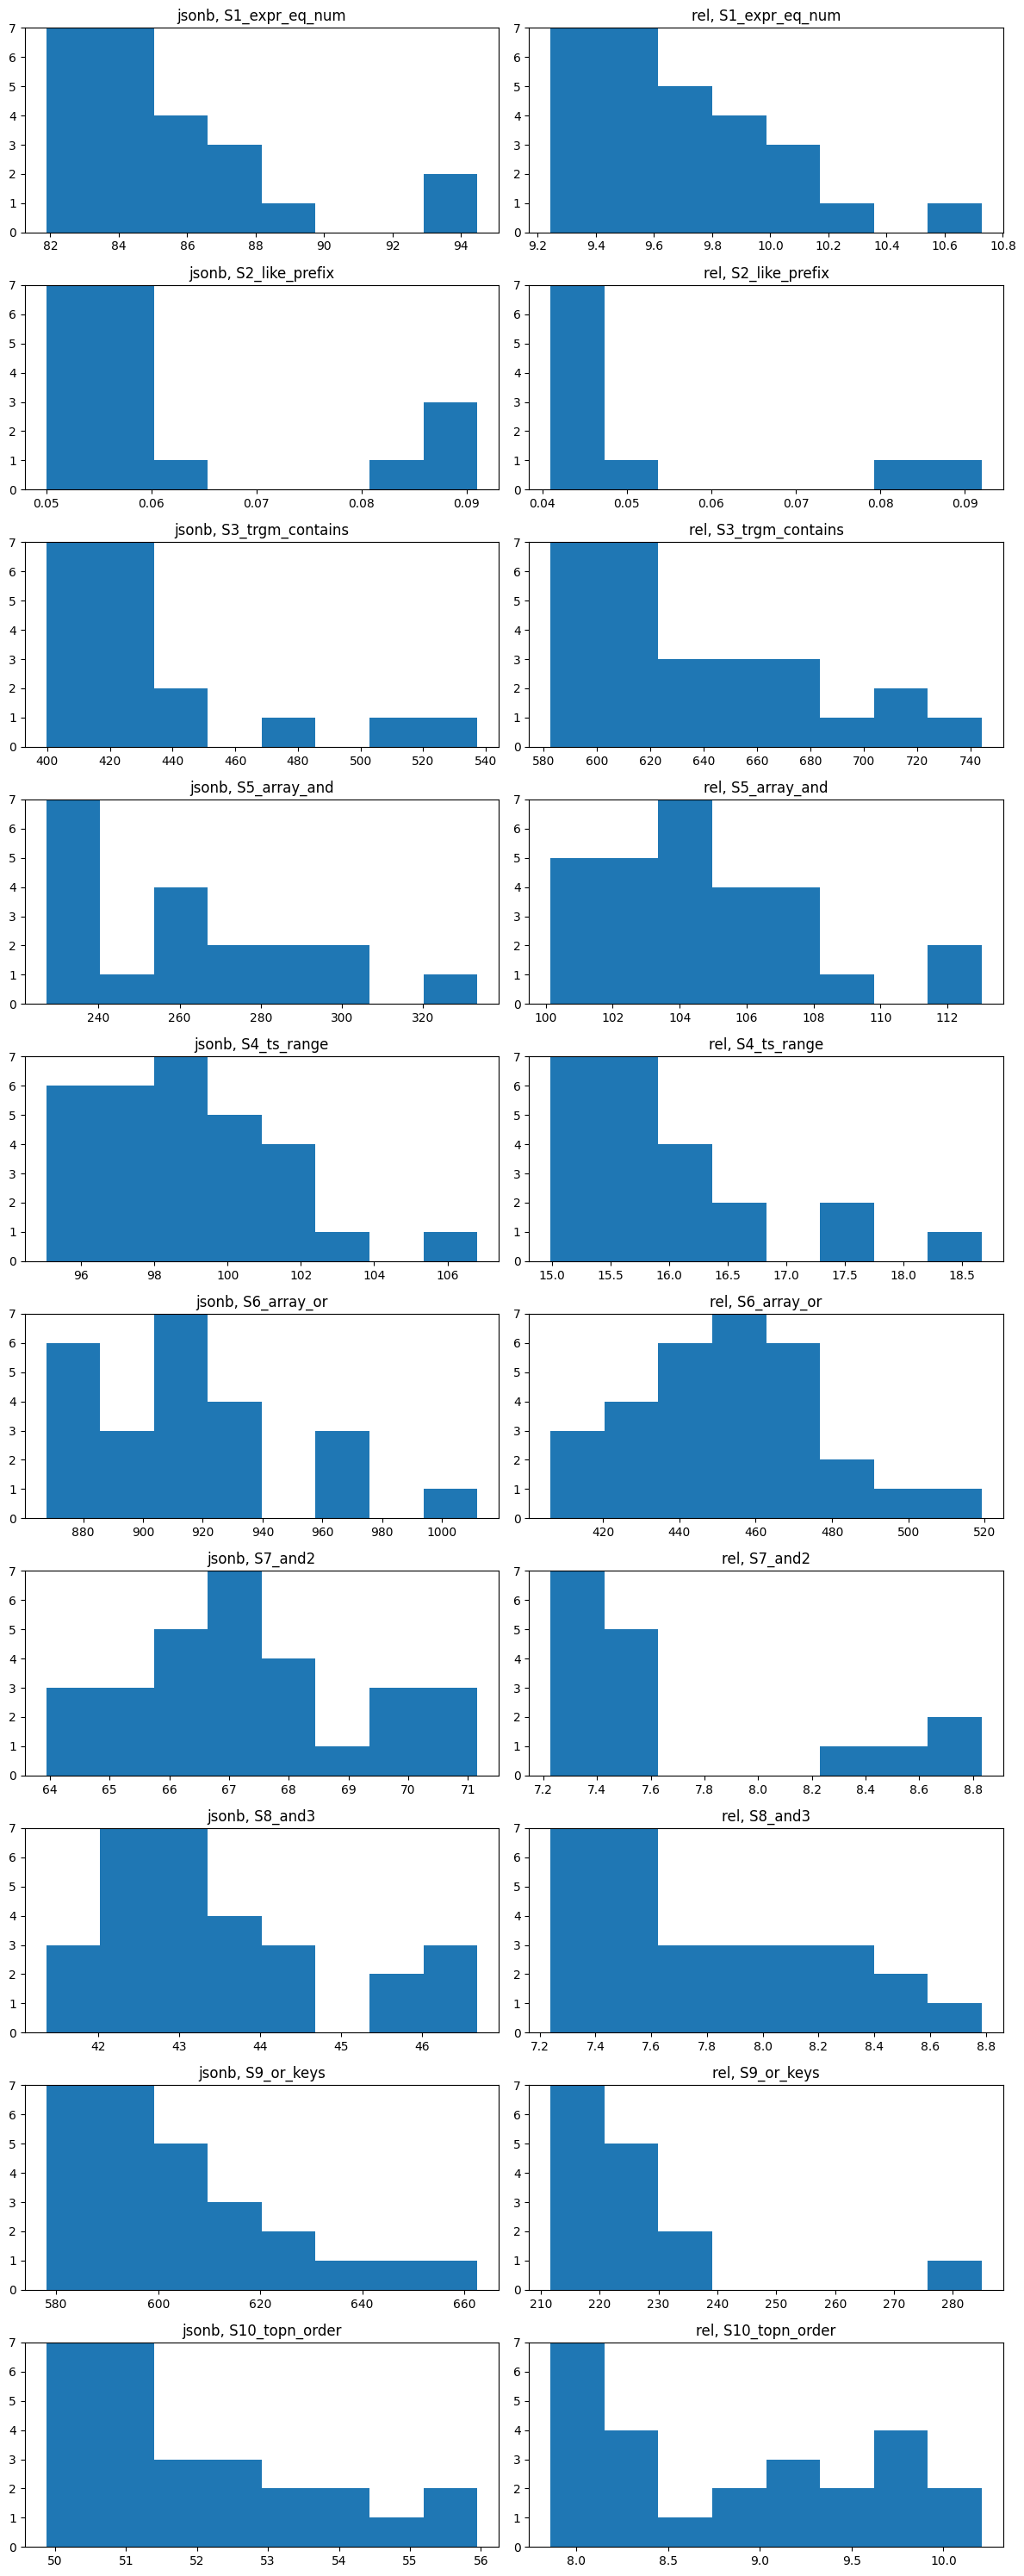

In [9]:
# Distribution Histograms
groups = indexed.variant.unique ()
db_types = indexed.type.unique ()


fig, axis = plt.subplots (len(groups), len (db_types), figsize = (12, 30))

for idx1, db_type in enumerate (db_types):
    for idx2, gtype in enumerate (groups):
        temp_df = indexed[(indexed['variant'] == groups[idx2]) &
                            (indexed['type'] == db_types[idx1])]['execution_ms']
        axis[idx2,idx1].hist (temp_df, bins =8)
        axis[idx2,idx1].set_title (f"{db_type}, {gtype}")
        axis[idx2,idx1].set_ylim (0,7)
plt.tight_layout ()
plt.show ()

In [10]:
indexed_drop = indexed.drop (['label', 'run_no'], axis =1)


#means for the gropus 
grouped_mean = indexed_drop.groupby (['type','variant']).mean ()
rel_group_mean = grouped_mean.loc ['rel', ].sort_index (ascending = True).copy ()
jsonb_group_mean = grouped_mean.loc ['jsonb',].sort_index (ascending = True).copy ()

#variance for the groups 
grouped_var = indexed_drop.groupby (['type','variant']).var (ddof=1)
rel_group_var = grouped_var.loc ['rel', ].sort_index (ascending = True).copy ()
jsonb_group_var = grouped_var.loc ['jsonb', ].sort_index (ascending = True).copy ()

# Difference between two means test (Not used in Final version)

In [8]:
# test for mean difference assuming normal distribution of the data

# H0: mean time latency for jsonb is the same as mean time latency for REL
# Ha: mean time latency for jsonb is greater than mean time latency for REL

def mean_variance_test (mean1, mean2, var1, var2, N_group):
    """One tail test for difference between two means.
    
    Assumptions:
    1. Samples are the same size (N_group)
    2. Unequal variance betweem two groups

    Input:
    1. mean1, mean2 - mean values per group
    2. var1, var2 - variance values per group 
    3. N_group - sample size
    """
    groups = mean1.index
    agg_values = dict ()
    for group in groups:
        mean_dif = mean1.loc [group,].values - mean2.loc [group,].values # mean difference between two groups
        var1v= var1.loc [group, ].values # variance group 1
        var2v= var2.loc [group, ].values # variance group 2
        pooled_var = np.sqrt ((var1v/N_group) + (var2v/N_group))
        t_value = mean_dif / pooled_var
        df = ((var1v/N_group + var2v/N_group)**2) / ((var1v/N_group)**2 / (N_group-1) + ((var2v/N_group)**2) / (N_group-1)) # degrees of freedom 
        p_val = 1 - t.cdf(t_value, df) # p-values
        agg_values[group] = p_val       
    return agg_values
    
    

In [9]:
pd.set_option('display.float_format', '{:.4f}'.format)
df_p =pd.DataFrame (mean_variance_test (jsonb_group_mean, rel_group_mean, jsonb_group_var, rel_group_var, N_group = 30)).T
df_p.rename (columns = {0 : 'Mean diff'}, inplace = True )
df_p = df_p.sort_values ('Mean diff', ascending = False)

df_p # p-values for all groups

,Mean diff
S3_trgm_contains,1.0000
S2_like_prefix,0.0000
S10_topn_order,0.0000
S1_expr_eq_num,0.0000
S4_ts_range,0.0000
S5_array_and,0.0000
S6_array_or,0.0000
S7_and2,0.0000
S8_and3,0.0000
S9_or_keys,0.0000


# Bootstrap Test

In [16]:
# actual realtive mean difference between two groups
mean_dif_realtive = (jsonb_group_mean['execution_ms'] - rel_group_mean['execution_ms'])/ jsonb_group_mean['execution_ms']
mean_dif_realtive

variant
S10_topn_order      0.831686
S1_expr_eq_num      0.886222
S2_like_prefix      0.244129
S3_trgm_contains   -0.475905
S4_ts_range         0.839813
S5_array_and        0.582690
S6_array_or         0.504525
S7_and2             0.887959
S8_and3             0.821279
S9_or_keys          0.632612
Name: execution_ms, dtype: float64

In [89]:
groups

numpy.ndarray

In [123]:
def bootstrap_test (df, groups, n_sim=10**5, threshold = 0.2, ci = 0.95, seed= 42):
    """
    Perform a one-sided bootstrap hypothesis test to determine whether 
    the mean execution time of the 'rel' type is at least a given percentage 
    faster than the 'jsonb' type for each variant group.

     Notes:
     1. The test is one-sided: it checks whether `rel` is at least `threshold` faster than `jsonb`.
     2. The bootstrap distribution is generated by resampling the means of both groups
        and computing the relative difference for each simulation.
    """
    results = dict ()
    np.random.seed (seed)
    for group in groups:
        jsonb_set = df[(df['variant'] == group) & (df['type']== 'jsonb')]['execution_ms']
        rel_set = df[(df['variant'] == group) & (df['type']== 'rel')]['execution_ms']
        realative_mean = (jsonb_set.mean () - rel_set.mean ()) / jsonb_set.mean ()

        jsonb_len = df[(df['variant'] == group) & (df['type']== 'jsonb')].shape [0]
        rel_len = df[(df['variant'] == group) & (df['type']== 'rel')].shape [0]

 #       sub_group = df[df['variant']== group]['execution_ms']
        
        jsonb_sim = np.random.choice (jsonb_set, size= [n_sim, jsonb_len], replace = True).mean (axis=1)
        rel_sim = np.random.choice (rel_set, size= [n_sim, rel_len], replace = True).mean (axis=1)
        dif_sim = (jsonb_sim - rel_sim) / jsonb_sim
        p = 1 - (np.sum (dif_sim >= threshold) / n_sim)
        lower_bound  = np.percentile(dif_sim, (1-ci)*100/2)
        upper_bound  = np.percentile(dif_sim, 100 - (1-ci)*100/2)
        
        if p <= (1- ci):
            decision = "Pass"
        else:
            decision = "Fail"
            
        results[group] = {"Expectation (%)" : realative_mean,
                          "Lower Bound (%)" : lower_bound,
                          "Upper Bound (%)" : upper_bound,
                          "Decision Threshold" : 1- ci,
                          "P-value" : p,
                          "Decision" : decision 
                         }            
    return results
    

In [124]:
boot_final = bootstrap_test (indexed_drop,groups)
boot_final_df = pd.DataFrame (boot_final).T

boot_final_df['Expectation (%)'] = boot_final_df['Expectation (%)'].astype ('float')
boot_final_df['Lower Bound (%)'] = boot_final_df['Lower Bound (%)'].astype ('float')
boot_final_df['Upper Bound (%)'] = boot_final_df['Upper Bound (%)'].astype ('float')
boot_final_df['Decision Threshold'] = boot_final_df['Decision Threshold'].astype ('float')
boot_final_df['P-value'] = boot_final_df['P-value'].astype ('float')

boot_final_df['Expectation (%)'] = round (boot_final_df['Expectation (%)'] * 100,2)
boot_final_df['Lower Bound (%)'] = round (boot_final_df['Lower Bound (%)'] * 100, 2)
boot_final_df['Upper Bound (%)'] = round (boot_final_df['Upper Bound (%)'] * 100, 2)
boot_final_df['P-value'] = round (boot_final_df['P-value'], 4)
boot_final_df = boot_final_df.sort_values ('P-value', ascending = False)

boot_final_df.index.name = "Variant"
boot_final_df
#boot_final_df.to_excel ("boot_strap_table.xlsx")

,Expectation (%),Lower Bound (%),Upper Bound (%),Decision Threshold,P-value,Decision
Variant,,,,,,
S3_trgm_contains,-47.59,-52.73,-42.35,0.05,1.0000,Fail
S2_like_prefix,24.41,15.29,31.79,0.05,0.1517,Fail
S1_expr_eq_num,88.62,88.43,88.82,0.05,0.0000,Pass
S5_array_and,58.27,56.68,59.92,0.05,0.0000,Pass
S4_ts_range,83.98,83.63,84.29,0.05,0.0000,Pass
S6_array_or,50.45,49.28,51.61,0.05,0.0000,Pass
S7_and2,88.80,88.52,89.04,0.05,0.0000,Pass
S8_and3,82.13,81.71,82.53,0.05,0.0000,Pass
S9_or_keys,63.26,62.29,64.05,0.05,0.0000,Pass


In [126]:
# Clculating for all variants at once
indexed_drop_overall = indexed_drop.copy ()
indexed_drop_overall['variant'] = "Overall"
indexed_drop_overall

,variant,execution_ms,type
3608,Overall,82.277,jsonb
3609,Overall,83.000,jsonb
3610,Overall,88.091,jsonb
3611,Overall,86.632,jsonb
3612,Overall,85.583,jsonb
...,...,...,...
4792,Overall,7.988,rel
4793,Overall,7.902,rel
4795,Overall,8.141,rel
4796,Overall,7.968,rel


In [128]:
overall_bootsrap = bootstrap_test (indexed_drop_overall, indexed_drop_overall['variant'].unique ())
pd.DataFrame (overall_bootsrap)

,Overall
Expectation (%),0.425832
Lower Bound (%),0.294225
Upper Bound (%),0.536376
Decision Threshold,0.05
P-value,0.0006
Decision,Pass


# Test for Growth (Not used in the Final version)

In [108]:
df = data[(~data['label'].str.contains ('unindexed'))].copy ()
df['type'] = df.apply (db_type, axis = 1) 
df[['Records N', 'Other']] = df['label'].str.split (" ", expand = True)
df =df[df['Records N'].str.contains ("N=")]
df['Records N'] = df['Records N'].str.strip ("N=").astype ("int")

In [113]:
import statsmodels.api as sm

# Log-transform
df['log_n'] = np.log(df['Records N'])
df['log_time'] = np.log(df['execution_ms'])

# Separate datasets
rel_df = df[df['type'] == 'rel']
jsonb_df = df[df['type'] == 'jsonb']


m_dict = dict ()

for group in groups:
    temp_jsonb = jsonb_df[jsonb_df['variant'] == group]
    temp_rel = rel_df[rel_df['variant'] == group]
    
    X_rel = sm.add_constant(temp_rel['log_n'])
    model_rel = sm.OLS(temp_rel['log_time'], X_rel).fit()

    X_jsonb = sm.add_constant(temp_jsonb['log_n'])
    model_jsonb = sm.OLS(temp_jsonb['log_time'], X_jsonb).fit()

    m_dict[group] = {'rel':model_rel,
                     'jsonb': model_jsonb}

    print("Rel slope:", model_rel.params['log_n'])
    print("JsonB slope:", model_jsonb.params['log_n'])


Rel slope: 1.074814975619487
JsonB slope: 1.0809142195969947
Rel slope: 0.8538221681601247
JsonB slope: 0.9858832829966631
Rel slope: 0.24767838957233773
JsonB slope: 0.27837981257705346
Rel slope: 1.0693708146723928
JsonB slope: 1.0871995389429534
Rel slope: 0.8343911061095926
JsonB slope: 1.0093484721358192
Rel slope: 1.0587761547790144
JsonB slope: 1.073692687353506
Rel slope: 1.062270761472998
JsonB slope: 1.0827235403475317
Rel slope: 1.0825022957793429
JsonB slope: 1.1024989184522949
Rel slope: 0.981396596647903
JsonB slope: 1.1007937924047904
Rel slope: 1.0244629486435382
JsonB slope: 0.973973307726588


In [118]:
import statsmodels.api as sm
df = data[(~data['label'].str.contains ('unindexed'))].copy ()
df['type'] = df.apply (db_type, axis = 1) 
df[['Records N', 'Other']] = df['label'].str.split (" ", expand = True)
df =df[df['Records N'].str.contains ("N=")]
df['Records N'] = df['Records N'].str.strip ("N=").astype ("int")


# Log-transform
df['log_n'] = np.log(df['Records N'])
df['log_time'] = np.log(df['execution_ms'])

# Separate datasets
#rel_df = df[df['type'] == 'rel']
#jsonb_df = df[df['type'] == 'jsonb']

m_dict = dict ()
# Assuming groups is defined, e.g., groups = df['variant'].unique()  # or your list of 10 variants
m_dict = dict()
for group in groups:
    temp_df = df[df['variant'] == group].copy()
    
    # Dummy for jsonb
    temp_df['is_jsonb'] = (temp_df['type'] == 'jsonb').astype(int)
    
    # Design matrix with interaction
    X = sm.add_constant(temp_df[['log_n', 'is_jsonb']])
    X['interaction'] = temp_df['log_n'] * temp_df['is_jsonb']
    
    # Fit combined model
    model = sm.OLS(temp_df['log_time'], X).fit()
    m_dict[group] = model
    
    # Extract rel slope (beta1), jsonb slope (beta1 + beta3), difference (beta3), and p-value
    rel_slope = model.params['log_n']
    diff_slope = model.params['interaction']
    jsonb_slope = rel_slope + diff_slope
    p_value = model.pvalues['interaction'] / 2  # One-sided p-value (since H1: diff > 0; assumes t-stat > 0)
    
    print(f"For group {group}:")
    print(f"  Rel slope: {rel_slope:.4f}")
    print(f"  JsonB slope: {jsonb_slope:.4f}")
    print(f"  Slope difference (JsonB - Rel): {diff_slope:.4f}")
    print(f"  One-sided p-value for difference > 0: {p_value:.4f}")
    print(f"  Full summary:\n{model.summary()}\n")

# Interpretation across 10 tests: For each group, if slope difference > 0 and p-value < 0.05, jsonb increases significantly faster.

For group S1_expr_eq_num:
  Rel slope: 1.0748
  JsonB slope: 1.0809
  Slope difference (JsonB - Rel): 0.0061
  One-sided p-value for difference > 0: 0.2597
  Full summary:
                            OLS Regression Results                            
Dep. Variable:               log_time   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.736e+04
Date:                Sun, 12 Oct 2025   Prob (F-statistic):          2.00e-276
Time:                        18:33:45   Log-Likelihood:                 62.011
No. Observations:                 240   AIC:                            -116.0
Df Residuals:                     236   BIC:                            -102.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err     

In [121]:
X

,const,log_n,is_jsonb,interaction
2280,1.0000,6.9078,1,6.9078
2281,1.0000,6.9078,1,6.9078
2282,1.0000,6.9078,1,6.9078
2283,1.0000,6.9078,1,6.9078
2284,1.0000,6.9078,1,6.9078
...,...,...,...,...
5969,1.0000,13.8155,0,0.0000
5970,1.0000,13.8155,0,0.0000
5971,1.0000,13.8155,0,0.0000
5972,1.0000,13.8155,0,0.0000
